In [1]:
# Cell-1

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats import multitest
import re
import warnings
import os
from itertools import combinations

# Suppress specific warnings that might clutter output
warnings.filterwarnings("ignore", message="The default of the `n_jobs` argument in `fast_power_transform` has been deprecated and will be changed to 1 in a future release.")
warnings.filterwarnings("ignore", category=UserWarning, module='statsmodels')

# --- Function to clean column names for statsmodels formula ---
def clean_column_name(name):
    """
    Cleans a column name to be compatible with statsmodels formulas.
    """
    cleaned_name = re.sub(r'[^a-zA-Z0-9_]', '_', name)
    cleaned_name = re.sub(r'_{2,}', '_', cleaned_name)
    cleaned_name = cleaned_name.strip('_')
    if cleaned_name and cleaned_name[0].isdigit():
        cleaned_name = '_' + cleaned_name
    return cleaned_name

# --- Define file paths ---
genetic_data_path = 'genotype_matrix.csv'
connectivity_data_path = 'Connectivity_matrix_all_subjects_region_pairs.csv'
covariates_data_path = 'subject_covariates.csv'
snp_metadata_path = 'snp_metadata.csv'

output_folder = 'Output_Version2'
os.makedirs(output_folder, exist_ok=True)

print("--- Starting Data Loading and Preprocessing ---")

# --- Step 1: Data Loading ---
try:
    genetic_data = pd.read_csv(genetic_data_path)
    connectivity_data = pd.read_csv(connectivity_data_path)
    covariates_data = pd.read_csv(covariates_data_path)
    snp_metadata = pd.read_csv(snp_metadata_path)
    print("All data files loaded successfully.")
except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure all files are in the correct directory.")
    exit()

--- Starting Data Loading and Preprocessing ---
All data files loaded successfully.


In [6]:
# Cell-2

# Apply Fisher's r-to-z transformation to connectivity data
connectivity_cols_to_transform = [col for col in connectivity_data.columns if connectivity_data[col].dtype == 'float64']
for col in connectivity_cols_to_transform:
    connectivity_data[col] = np.arctanh(np.clip(connectivity_data[col], -0.999999, 0.999999))
print("Fisher's r-to-z transformation applied to connectivity data.")

# Harmonize Subject ID column names
if 'Subject ID' in connectivity_data.columns:
    connectivity_data.rename(columns={'Subject ID': 'Subject_ID'}, inplace=True)
if 'subject_id' in covariates_data.columns:
    covariates_data.rename(columns={'subject_id': 'Subject_ID'}, inplace=True)
if 'SubjectId' in genetic_data.columns:
    genetic_data.rename(columns={'SubjectId': 'Subject_ID'}, inplace=True)
print("Subject ID column names harmonized.")

# --- Filter out the specified subject ---
subject_to_exclude = '029_S_2395'
genetic_data = genetic_data[genetic_data['Subject_ID'] != subject_to_exclude]
connectivity_data = connectivity_data[connectivity_data['Subject_ID'] != subject_to_exclude]
covariates_data = covariates_data[covariates_data['Subject_ID'] != subject_to_exclude]
print(f"Subject '{subject_to_exclude}' has been excluded from all datasets.")

# --- Step 2: Merging Data for Analysis ---
merged_data = pd.merge(genetic_data, covariates_data, on='Subject_ID', how='inner')
merged_data = pd.merge(merged_data, connectivity_data, on='Subject_ID', how='inner')
print(f"Dataframes merged successfully. Total subjects: {len(merged_data)}")

# --- Preprocessing for model fitting ---
if 'group' in merged_data.columns:
    merged_data.rename(columns={'group': 'Subtype'}, inplace=True)

# Clean connectivity column names to avoid formula errors
original_connectivity_columns_in_df = [col for col in connectivity_data.columns if col != 'Subject_ID']
cleaned_connectivity_name_map = {col: clean_column_name(col) for col in original_connectivity_columns_in_df}
merged_data.rename(columns=cleaned_connectivity_name_map, inplace=True)
print("Connectivity column names cleaned.")

# Convert categorical variables and set Control as the new reference
merged_data['Subtype'] = pd.Categorical(merged_data['Subtype'], categories=['Control', 'TypAD', 'AsymAD', 'LowNFT'], ordered=False)
merged_data['scanner'] = pd.Categorical(merged_data['scanner'])
merged_data['scan_type'] = pd.Categorical(merged_data['scan_type'])

print("\nData prepared for model fitting.")

Fisher's r-to-z transformation applied to connectivity data.
Subject ID column names harmonized.
Subject '029_S_2395' has been excluded from all datasets.
Dataframes merged successfully. Total subjects: 187
Connectivity column names cleaned.

Data prepared for model fitting.


In [7]:
# Cell-3

print("\n--- Starting Full Automated Regression Pipeline ---")

# --- Step 3: Preprocessing and Feature Identification ---
snp_columns = [col for col in merged_data.columns if col.startswith('rs')]
connectivity_columns = [col for col in merged_data.columns if 'Connectivity' in col]

snp_metadata['comparison_group'] = snp_metadata.apply(lambda row: '_vs_'.join(sorted([str(row['Case']), str(row['Control'])])), axis=1)
gwas_snp_groups = {}
unique_comparison_groups = snp_metadata['comparison_group'].unique()
for group_name in unique_comparison_groups:
    rs_ids_for_group = snp_metadata[snp_metadata['comparison_group'] == group_name]['SNP'].tolist()
    actual_snp_cols_in_data = [
        col for col in snp_columns
        if any(col.startswith(rs_id + '_') for rs_id in rs_ids_for_group)
    ]
    gwas_snp_groups[group_name] = actual_snp_cols_in_data

# --- Step 4: OLS Regression Loop ---
all_model_results = []
MIN_OBS_FOR_MODEL = 10
model_formula_template = "{connectivity_col} ~ {snp_col} * C(Subtype, Treatment('Control')) + age + sex + C(scanner) + C(scan_type)"

pairwise_subtypes = ['AsymAD', 'TypAD', 'LowNFT']
pairwise_combinations = list(combinations(pairwise_subtypes, 2))

# Flatten the list of all SNPs to loop through them
all_gwas_snps = {snp for snps in gwas_snp_groups.values() for snp in snps}

processed_count = 0
total_combinations = len(all_gwas_snps) * len(connectivity_columns)

for snp_col in all_gwas_snps:
    for connectivity_col in connectivity_columns:
        processed_count += 1
        
        # Select and clean the subset of data for this model
        cols_for_model = [connectivity_col, snp_col, 'Subtype', 'age', 'sex', 'scanner', 'scan_type']
        model_data_subset = merged_data[cols_for_model].dropna()

        # Check for model feasibility
        if len(model_data_subset) < MIN_OBS_FOR_MODEL:
            continue
        if model_data_subset[snp_col].std() == 0 or model_data_subset[connectivity_col].std() == 0:
            continue
        if len(model_data_subset['Subtype'].dropna().unique()) < 2:
            continue

        result_row = {
            'SNP_Name': snp_col,
            'Connectivity_Name': connectivity_col,
            'R_squared': np.nan,
        }
        
        # Determine GWAS group
        gwas_comp = [name for name, snps in gwas_snp_groups.items() if snp_col in snps]
        result_row['GWAS_Comparison'] = gwas_comp[0] if gwas_comp else 'N/A'

        try:
            model = smf.ols(model_formula_template.format(connectivity_col=connectivity_col, snp_col=snp_col), data=model_data_subset).fit()
            param_names = model.params.index.tolist()
            result_row['R_squared'] = model.rsquared

            # --- Get results for contrasts against the reference group (Control) ---
            for subtype in pairwise_subtypes:
                param_name = f"{snp_col}:C(Subtype, Treatment('Control'))[T.{subtype}]"
                if param_name in param_names:
                    result_row[f'P_{subtype}_vs_Control'] = model.pvalues[param_name]
                    result_row[f'Coeff_{subtype}_vs_Control'] = model.params[param_name]

            # --- Get results for custom contrasts (non-reference groups) ---
            for group1, group2 in pairwise_combinations:
                param1_name = f"{snp_col}:C(Subtype, Treatment('Control'))[T.{group1}]"
                param2_name = f"{snp_col}:C(Subtype, Treatment('Control'))[T.{group2}]"

                if param1_name in param_names and param2_name in param_names:
                    contrast_matrix = np.zeros(len(param_names))
                    contrast_matrix[param_names.index(param1_name)] = 1
                    contrast_matrix[param_names.index(param2_name)] = -1
                    
                    test_result = model.t_test(contrast_matrix)
                    p_value = test_result.pvalue.item() if isinstance(test_result.pvalue, np.ndarray) else test_result.pvalue
                    coefficient = test_result.effect.item() if isinstance(test_result.effect, np.ndarray) else test_result.effect

                    result_row[f'P_{group1}_vs_{group2}'] = p_value
                    result_row[f'Coeff_{group1}_vs_{group2}'] = coefficient
            
            all_model_results.append(result_row)
            
        except Exception:
            # Skip models that fail to converge or have other issues
            pass

        if processed_count % 100000 == 0:
            print(f"Processed {processed_count}/{total_combinations} combinations...")


# --- Step 5: Save All Raw Results ---
results_df = pd.DataFrame(all_model_results)
results_df.to_csv(os.path.join(output_folder, 'all_regression_result.csv'), index=False)
print("\n'all_regression_result.csv' saved.")

# --- Step 6: Apply FDR Correction ---
p_value_cols = [col for col in results_df.columns if col.startswith('P_') and '_vs_' in col]
corrected_df = results_df.copy()

for p_col in p_value_cols:
    valid_p_values = corrected_df[p_col].dropna()
    original_indices = valid_p_values.index
    if len(valid_p_values) > 0:
        reject, pvals_corrected, _, _ = multitest.multipletests(pvals=valid_p_values, alpha=0.05, method='fdr_bh')
        corrected_df.loc[original_indices, f'P_FDR{p_col[1:]}'] = pvals_corrected

corrected_df.to_csv(os.path.join(output_folder, 'all_regression_result_FDR.csv'), index=False)
print("'all_regression_result_FDR.csv' saved.")

# --- Step 7: Filter for Significant Results ---
fdr_cols = [col for col in corrected_df.columns if col.startswith('P_FDR')]
combined_mask = pd.DataFrame(False, index=corrected_df.index, columns=[1])
for fdr_col in fdr_cols:
    if fdr_col in corrected_df.columns:
        mask = corrected_df[fdr_col] < 0.05
        combined_mask = combined_mask | mask.to_frame()
        
significant_results = corrected_df[combined_mask.iloc[:,0]].copy()

significant_results.to_csv(os.path.join(output_folder, 'significant_result.csv'), index=False)
print("'significant_result.csv' saved.")

print("\n--- Pipeline Complete. ---")


--- Starting Full Automated Regression Pipeline ---
Processed 100000/4011033 combinations...
Processed 200000/4011033 combinations...
Processed 300000/4011033 combinations...
Processed 400000/4011033 combinations...
Processed 500000/4011033 combinations...
Processed 600000/4011033 combinations...
Processed 700000/4011033 combinations...
Processed 800000/4011033 combinations...
Processed 900000/4011033 combinations...
Processed 1000000/4011033 combinations...
Processed 1100000/4011033 combinations...
Processed 1200000/4011033 combinations...
Processed 1300000/4011033 combinations...
Processed 1400000/4011033 combinations...
Processed 1500000/4011033 combinations...
Processed 1600000/4011033 combinations...
Processed 1700000/4011033 combinations...
Processed 1800000/4011033 combinations...
Processed 1900000/4011033 combinations...
Processed 2000000/4011033 combinations...
Processed 2100000/4011033 combinations...
Processed 2200000/4011033 combinations...
Processed 2300000/4011033 combin

In [8]:
# --- Step 7: Filter for Significant Results with Coeff Threshold ---
fdr_cols = [col for col in corrected_df.columns if col.startswith('P_FDR')]
combined_mask = pd.DataFrame(False, index=corrected_df.index, columns=[1])
min_abs_coeff_threshold = 0.3

for fdr_col in fdr_cols:
    # Find the corresponding raw p-value column name and coefficient column name
    raw_p_col = 'P' + fdr_col[5:]
    coeff_col = 'Coeff' + fdr_col[5:]
    
    # Check if all required columns exist in the DataFrame
    if fdr_col in corrected_df.columns and coeff_col in corrected_df.columns:
        # Create a mask for significance (p-value < 0.05) and effect size (abs(coeff) > 0.3)
        p_mask = corrected_df[fdr_col] < 0.05
        coeff_mask = corrected_df[coeff_col].abs() > min_abs_coeff_threshold
        
        # Combine the masks for the current comparison
        current_mask = p_mask & coeff_mask
        
        # Add the current mask to the overall combined mask
        combined_mask = combined_mask | current_mask.to_frame()

significant_results = corrected_df[combined_mask.iloc[:,0]].copy()

significant_results.to_csv(os.path.join(output_folder, 'significant_result.csv'), index=False)
print("'significant_result.csv' saved.")

'significant_result.csv' saved.


In [6]:
# Cell-4

import pandas as pd
import os
import re

print("\n--- Starting VEP and GWAS-specific file generation ---")

# --- Define file paths and output folders ---
input_file_path = os.path.join('Output_Version2', 'significant_result.csv')
vep_output_folder = 'VEP_Input_Files'
gwas_output_folder = 'GWAS_Results_by_Comparison'
os.makedirs(vep_output_folder, exist_ok=True)
os.makedirs(gwas_output_folder, exist_ok=True)

# --- Define the GWAS pairs to be processed ---
gwas_pairs = [
    'Asym AD_vs_Control',
    'Control_vs_Typical AD',
    'Low NFT AD_vs_Typical AD',
    'Asym AD_vs_Typical AD',
    'Control_vs_Low NFT AD',
    'Asym AD_vs_Low NFT AD'
]

# --- Define the columns for the CSV output files ---
csv_columns = [
    'SNP_Name', 'Connectivity_Name', 'R_squared',
    'P_AsymAD_vs_Control', 'Coeff_AsymAD_vs_Control',
    'P_TypAD_vs_Control', 'Coeff_TypAD_vs_Control',
    'P_LowNFT_vs_Control', 'Coeff_LowNFT_vs_Control',
    'P_AsymAD_vs_TypAD', 'Coeff_AsymAD_vs_TypAD',
    'P_AsymAD_vs_LowNFT', 'Coeff_AsymAD_vs_LowNFT',
    'P_TypAD_vs_LowNFT', 'Coeff_TypAD_vs_LowNFT',
    'P_FDR_AsymAD_vs_Control', 'P_FDR_TypAD_vs_Control',
    'P_FDR_LowNFT_vs_Control', 'P_FDR_AsymAD_vs_TypAD',
    'P_FDR_AsymAD_vs_LowNFT', 'P_FDR_TypAD_vs_LowNFT'
]

# --- Function to generate VEP and CSV files for a given GWAS pair ---
def generate_files_for_gwas_pair(df, gwas_pair):
    print(f"\nProcessing files for GWAS pair: '{gwas_pair}'")
    
    # Filter the DataFrame for the specific GWAS pair
    filtered_df = df[df['GWAS_Comparison'] == gwas_pair].copy()
    
    if filtered_df.empty:
        print(f"No significant results found for '{gwas_pair}'. Skipping file generation.")
        return

    # --- 1. Generate VEP input .txt file with unique, cleaned SNP names ---
    vep_file_name = f"{gwas_pair.replace(' ', '_').replace(':', '_')}_VEP.txt"
    vep_file_path = os.path.join(vep_output_folder, vep_file_name)
    
    # Remove the trailing _A, _T, etc. and get unique SNPs
    filtered_df['SNP_Clean'] = filtered_df['SNP_Name'].apply(lambda x: re.sub(r'_[ATCG]$', '', x))
    unique_snps = filtered_df['SNP_Clean'].unique()
    
    pd.Series(unique_snps).to_csv(vep_file_path, index=False, header=False)
    print(f"Generated VEP file: '{vep_file_path}' ({len(unique_snps)} unique SNPs)")
    
    # --- 2. Generate corresponding .csv file with specified columns ---
    csv_file_name = f"{gwas_pair.replace(' ', '_').replace(':', '_')}_results.csv"
    csv_file_path = os.path.join(gwas_output_folder, csv_file_name)
    
    # Select the columns, handling potential missing columns
    selected_columns = [col for col in csv_columns if col in filtered_df.columns]
    filtered_df[selected_columns].to_csv(csv_file_path, index=False)
    print(f"Generated CSV file: '{csv_file_path}' ({len(filtered_df)} rows)")


# --- Main execution loop ---
try:
    significant_results = pd.read_csv(input_file_path)
    
    for pair in gwas_pairs:
        generate_files_for_gwas_pair(significant_results, pair)

    print("\n--- File generation complete. You can now use the VEP files for annotation. ---")

except FileNotFoundError:
    print(f"Error: The input file '{input_file_path}' was not found.")


--- Starting VEP and GWAS-specific file generation ---

Processing files for GWAS pair: 'Asym AD_vs_Control'
Generated VEP file: 'VEP_Input_Files/Asym_AD_vs_Control_VEP.txt' (955 unique SNPs)
Generated CSV file: 'GWAS_Results_by_Comparison/Asym_AD_vs_Control_results.csv' (5813 rows)

Processing files for GWAS pair: 'Control_vs_Typical AD'
Generated VEP file: 'VEP_Input_Files/Control_vs_Typical_AD_VEP.txt' (745 unique SNPs)
Generated CSV file: 'GWAS_Results_by_Comparison/Control_vs_Typical_AD_results.csv' (4797 rows)

Processing files for GWAS pair: 'Low NFT AD_vs_Typical AD'
Generated VEP file: 'VEP_Input_Files/Low_NFT_AD_vs_Typical_AD_VEP.txt' (649 unique SNPs)
Generated CSV file: 'GWAS_Results_by_Comparison/Low_NFT_AD_vs_Typical_AD_results.csv' (4317 rows)

Processing files for GWAS pair: 'Asym AD_vs_Typical AD'
Generated VEP file: 'VEP_Input_Files/Asym_AD_vs_Typical_AD_VEP.txt' (906 unique SNPs)
Generated CSV file: 'GWAS_Results_by_Comparison/Asym_AD_vs_Typical_AD_results.csv' (554


--- Starting Matplotlib Heatmap Generation for All Six Comparisons ---
Generating heatmap for 'AsymAD vs. Control'...
  Heatmap saved to 'Output_Version2/AsymAD_vs_Control_Top20_Heatmap.png'


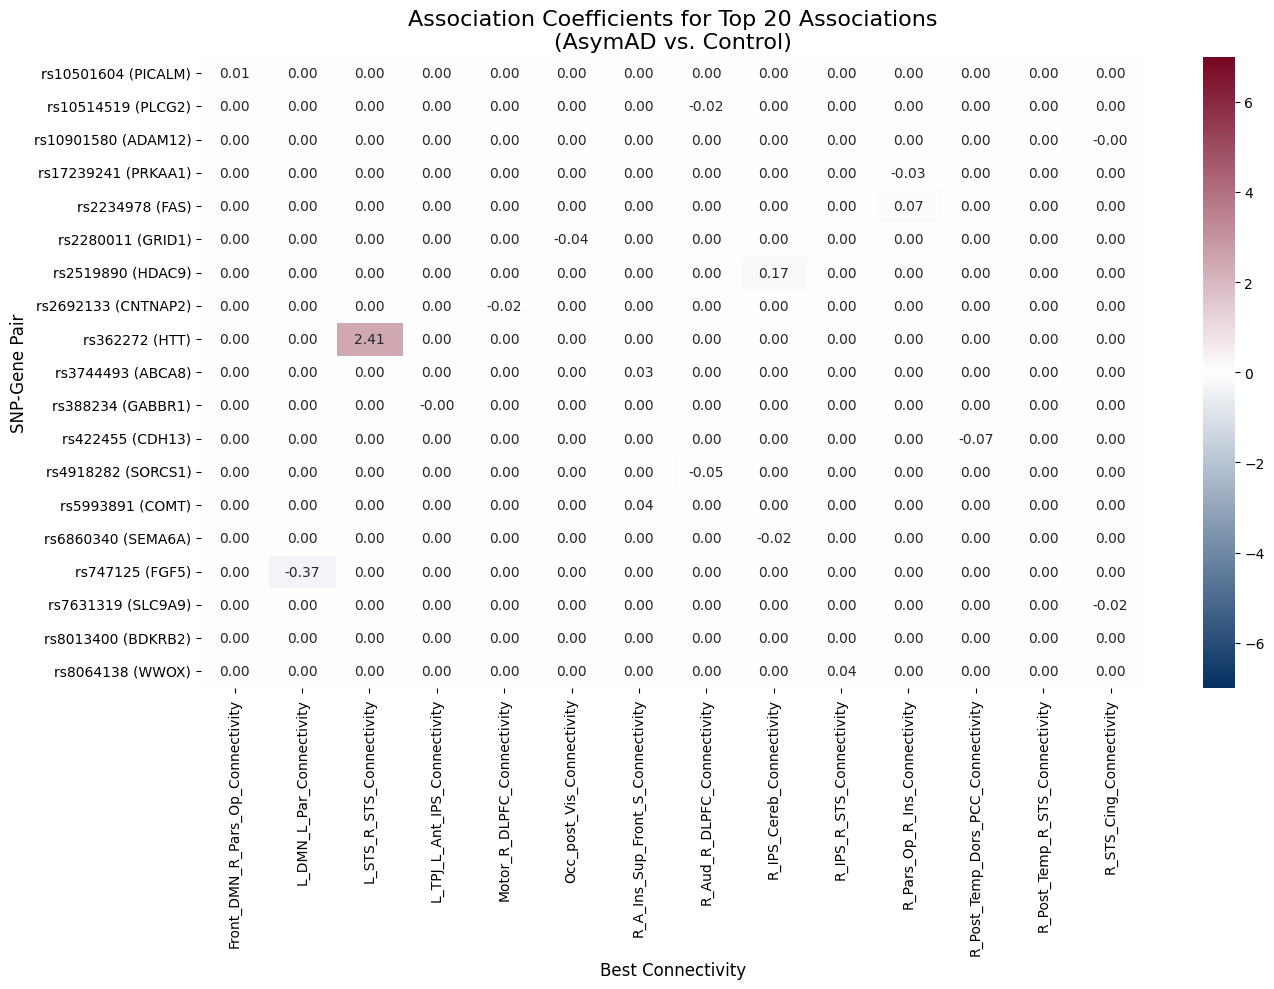

Generating heatmap for 'AsymAD vs. TypAD'...
  Heatmap saved to 'Output_Version2/AsymAD_vs_TypAD_Top20_Heatmap.png'


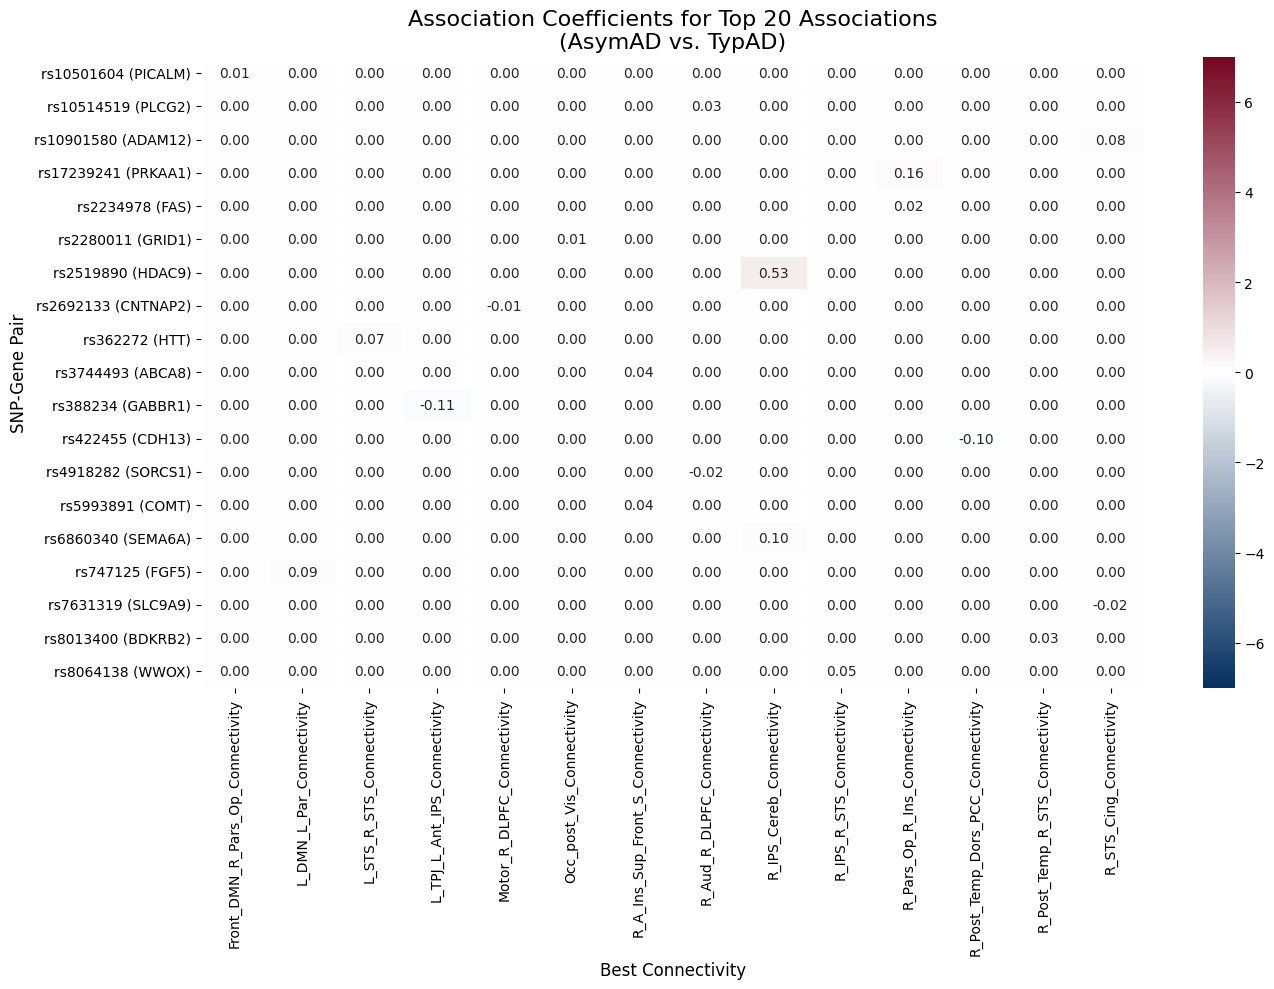

Generating heatmap for 'AsymAD vs. LowNFT'...
  Heatmap saved to 'Output_Version2/AsymAD_vs_LowNFT_Top20_Heatmap.png'


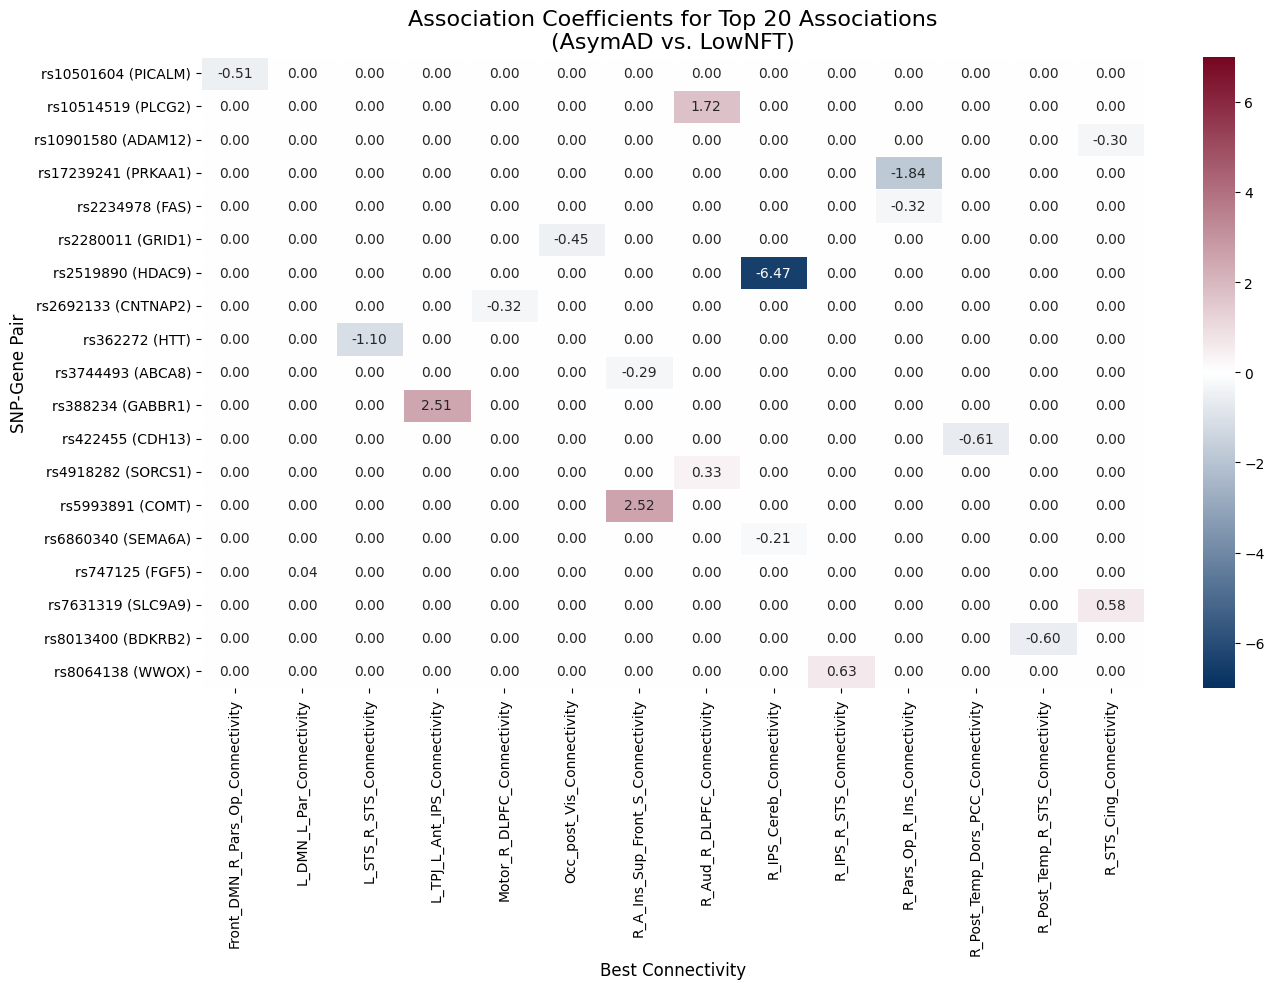

Generating heatmap for 'TypAD vs. Control'...
  Heatmap saved to 'Output_Version2/TypAD_vs_Control_Top20_Heatmap.png'


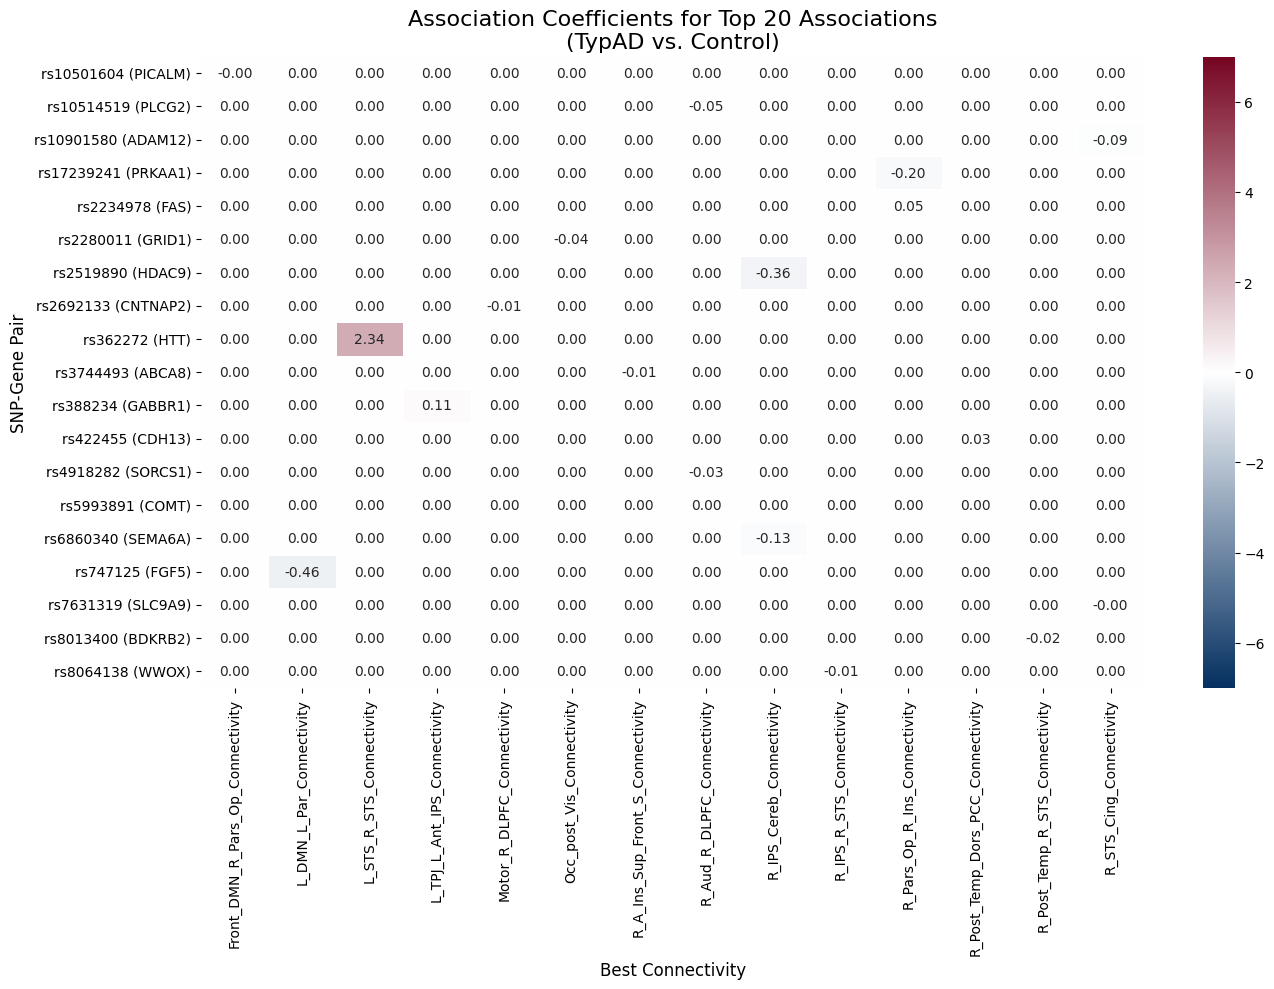

Generating heatmap for 'TypAD vs. LowNFT'...
  Heatmap saved to 'Output_Version2/TypAD_vs_LowNFT_Top20_Heatmap.png'


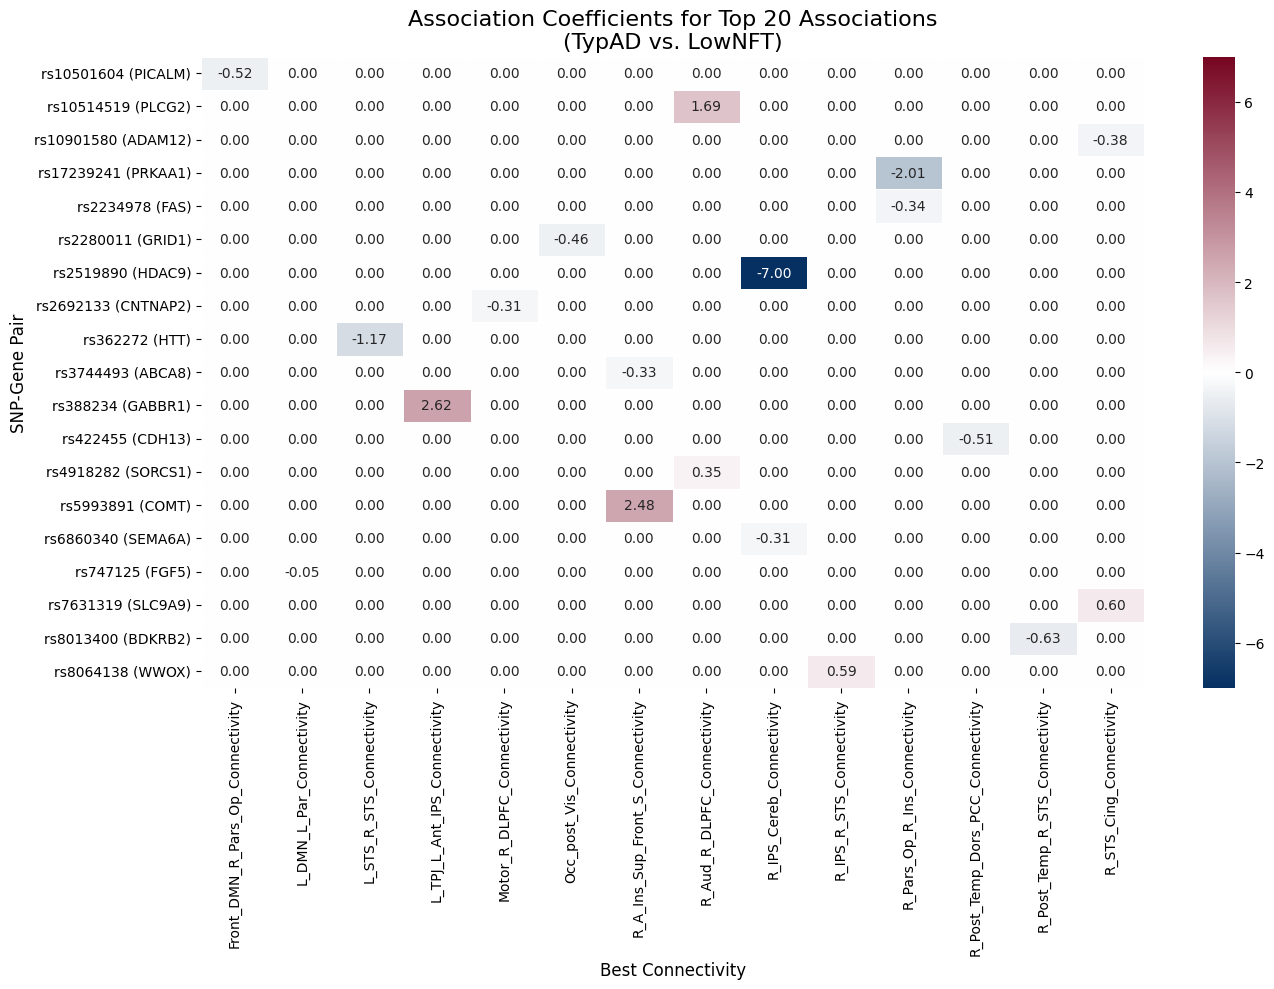

Generating heatmap for 'LowNFT vs. Control'...
  Heatmap saved to 'Output_Version2/LowNFT_vs_Control_Top20_Heatmap.png'


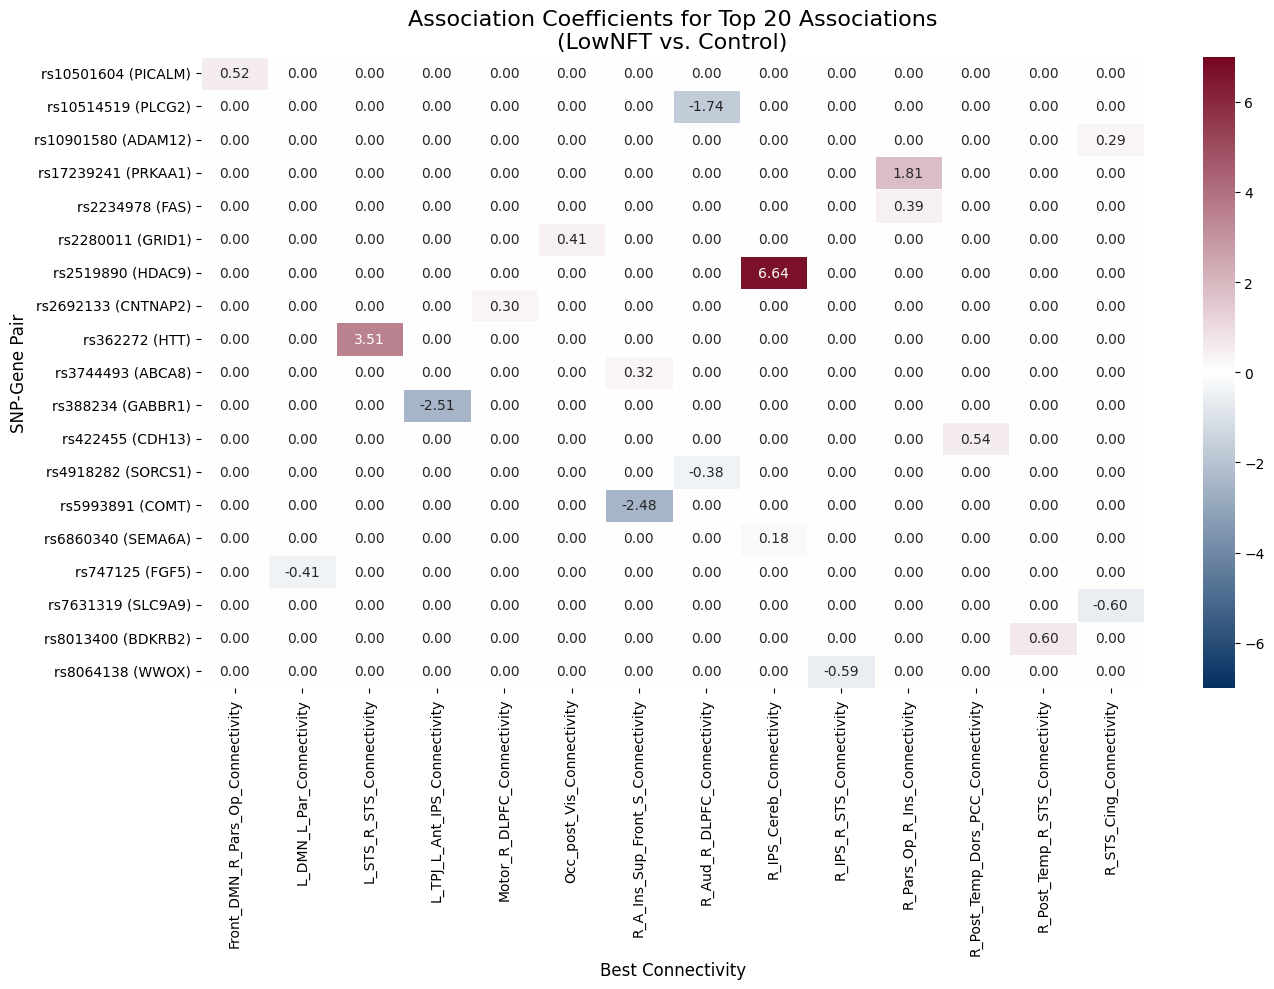


All heatmaps generated. Cell-5 code executed.


In [21]:
# Cell-5

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import re
from matplotlib.colors import LinearSegmentedColormap

print("\n--- Starting Matplotlib Heatmap Generation for All Six Comparisons ---")

# Define the output folder
output_folder = 'Output_Version2'
os.makedirs(output_folder, exist_ok=True)

# Define the file paths for the provided data
gene_info_path = 'GWAS_Results_by_Comparison/Gene_Info_AsymAD_vs_Control.csv'
results_path = 'GWAS_Results_by_Comparison/Asym_AD_vs_Control_results.csv'

# Check if the files exist before proceeding
if not os.path.exists(gene_info_path) or not os.path.exists(results_path):
    print("Error: The necessary input files for this cell were not found.")
else:
    # Load the gene info and results data
    gene_info_df = pd.read_csv(gene_info_path)
    results_df = pd.read_csv(results_path)
    
    # Rename the column in gene_info_df to match the format of results_df
    gene_info_df.rename(columns={'SNP name': 'SNP_Name'}, inplace=True)

    # Clean the SNP name in both files to allow for merging
    gene_info_df['SNP_Clean'] = gene_info_df['SNP_Name'].apply(lambda x: re.sub(r'_[ATCG]$', '', x))
    results_df['SNP_Clean'] = results_df['SNP_Name'].apply(lambda x: re.sub(r'_[ATCG]$', '', x))
    
    # Merge the two dataframes on the cleaned SNP name
    merged_df = pd.merge(results_df, gene_info_df, on='SNP_Clean', how='inner', suffixes=('_results', '_gene'))
    
    # Define the six comparisons and their corresponding coefficient columns
    comparisons = {
        'AsymAD vs. Control': 'Coeff_AsymAD_vs_Control',
        'AsymAD vs. TypAD': 'Coeff_AsymAD_vs_TypAD',
        'AsymAD vs. LowNFT': 'Coeff_AsymAD_vs_LowNFT',
        'TypAD vs. Control': 'Coeff_TypAD_vs_Control',
        'TypAD vs. LowNFT': 'Coeff_TypAD_vs_LowNFT',
        'LowNFT vs. Control': 'Coeff_LowNFT_vs_Control',
    }
    
    # Filter for the top 20 unique SNP-Gene-Connectivity combinations
    top_20_associations = merged_df.sort_values(
        by='Significance_Count', ascending=False
    ).drop_duplicates(
        subset=['SNP_Clean', 'Gene Name', 'Best Connectivity']
    ).head(20).copy()

    # Create a unique identifier for the rows
    top_20_associations['SNP_Gene_Pair'] = top_20_associations['SNP_Name_gene'] + ' (' + top_20_associations['Gene Name'] + ')'
    
    # Calculate global min and max for consistent color scale
    all_coeffs = top_20_associations[[col for col in comparisons.values()]].to_numpy().flatten()
    max_abs_coeff = np.nanmax(np.abs(all_coeffs))
    vmin = -max_abs_coeff
    vmax = max_abs_coeff

    # Define the custom color map (blue to white to red)
    cmap = LinearSegmentedColormap.from_list("blue_white_red", ["#053061", "white", "#760521"])

    # Iterate through each comparison and generate a separate heatmap
    for title, coeff_column in comparisons.items():
        print(f"Generating heatmap for '{title}'...")

        # Create the heatmap data matrix for the current comparison.
        heatmap_data = top_20_associations.pivot_table(
            index='SNP_Gene_Pair',
            columns='Best Connectivity',
            values=coeff_column,
            fill_value=0
        )
            
        plt.figure(figsize=(14, 10))
        sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap=cmap, linewidths=.5, vmin=vmin, vmax=vmax)
        plt.title(f'Association Coefficients for Top 20 Associations\n({title})', fontsize=16)
        plt.xlabel('Best Connectivity', fontsize=12)
        plt.ylabel('SNP-Gene Pair', fontsize=12)
        plt.tight_layout()

        # Save the plot
        file_name = f"{title.replace(' ', '_').replace('.', '')}_Top20_Heatmap.png"
        file_path = os.path.join(output_folder, file_name)
        plt.savefig(file_path, dpi=300)
        print(f"  Heatmap saved to '{file_path}'")
        plt.show()
        plt.close()

print("\nAll heatmaps generated. Cell-5 code executed.")


In [30]:
# Cell-6

import pandas as pd
import numpy as np
import os
import re
from io import StringIO
from itertools import combinations

print("\n--- Starting BrainNet Viewer File Generation ---")

# Define the output folder
output_folder = 'Output_Version2'
bnv_output_folder = os.path.join(output_folder, 'BNV_Files')
os.makedirs(bnv_output_folder, exist_ok=True)

# --- HARDCODED MSDL Atlas Data ---
HARDCODED_MSDL_ROI_LABELS = ['Auditory_L', 'Auditory_R', 'Striate', 'DMN_L', 'DMN_Med', 'DMN_Front', 'DMN_R', 'Occ_post', 'Motor', 'DLPFC_R', 'Front_pol_R', 'Par_R', 'Post_Temp_R', 'Basal', 'Par_L', 'DLPFC_L', 'Front_pol_L', 'IPS_L', 'IPS_R', 'LOC_L', 'Vis', 'LOC_R', 'D_ACC', 'V_ACC', 'A_Ins_R', 'STS_L', 'STS_R', 'TPJ_L', 'Broca', 'Sup_Front_S', 'TPJ_R', 'Pars_Op_R', 'Cereb', 'Dors_PCC', 'Ins_L', 'Cing', 'Ins_R', 'Ant_IPS_L', 'Ant_IPS_R']
HARDCODED_MSDL_COORDS = np.array([[-52.5, -22.5, 7.5], [52.5, -22.5, 7.5], [-2.5, -82.5, 17.5], [-57.5, -42.5, 27.5], [-2.5, -57.5, 37.5], [-2.5, 47.5, 17.5], [57.5, -47.5, 27.5], [-2.5, -82.5, 47.5], [-2.5, -22.5, 57.5], [42.5, 37.5, 37.5], [27.5, 62.5, 7.5], [47.5, -67.5, 47.5], [52.5, -42.5, 7.5], [-2.5, -12.5, -7.5], [-47.5, -67.5, 47.5], [-42.5, 37.5, 37.5], [-27.5, 62.5, 7.5], [-42.5, -67.5, 37.5], [42.5, -67.5, 37.5], [-42.5, -77.5, 7.5], [-2.5, -92.5, -7.5], [42.5, -77.5, 7.5], [-2.5, 27.5, 27.5], [-2.5, 12.5, 7.5], [37.5, 12.5, 7.5], [-52.5, -22.5, -7.5], [52.5, -22.5, -7.5], [-52.5, -57.5, 7.5], [-42.5, 17.5, 27.5], [-2.5, 57.5, 37.5], [52.5, -57.5, 7.5], [42.5, 17.5, 27.5], [-2.5, -67.5, -27.5], [-2.5, -47.5, 47.5], [-37.5, 12.5, 7.5], [-2.5, 7.5, 27.5], [37.5, 12.5, 7.5], [-37.5, -67.5, 27.5], [37.5, -67.5, 27.5]])
msdl_label_to_index = {label: i for i, label in enumerate(HARDCODED_MSDL_ROI_LABELS)}
region_name_abbr_to_msdl_map = {'L_Aud':'Auditory_L','R_Aud':'Auditory_R','L_DMN':'DMN_L','Med_DMN':'DMN_Med','Front_DMN':'DMN_Front','R_DMN':'DMN_R','L_Par':'Par_L','R_Par':'Par_R','L_DLPFC':'DLPFC_L','R_DLPFC':'DLPFC_R','L_Front_pol':'Front_pol_L','R_Front_pol':'Front_pol_R','L_IPS':'IPS_L','R_IPS':'IPS_R','L_LOC':'LOC_L','R_LOC':'LOC_R','L_STS':'STS_L','R_STS':'STS_R','L_TPJ':'TPJ_L','R_TPJ':'TPJ_R','L_Ins':'Ins_L','R_Ins':'Ins_R','L_Ant_IPS':'Ant_IPS_L','R_Ant_IPS':'Ant_IPS_R','D_ACC':'D_ACC','V_ACC':'V_ACC','A_Ins_R':'A_Ins_R','Broca':'Broca','Sup_Front_S':'Sup_Front_S','Pars_Op_R':'Pars_Op_R','R_Pars_Op':'Pars_Op_R','R_A_Ins':'A_Ins_R','R_Post_Temp':'Post_Temp_R','Vis':'Vis','Basal':'Basal','Striate':'Striate','Motor':'Motor','Occ_post':'Occ_post','Post_Temp_R':'Post_Temp_R','Dors_PCC':'Dors_PCC','Cing':'Cing','Cereb':'Cereb'}

# --- Helper functions ---
def clean_column_name(name):
    """Cleans a column name for compatibility."""
    cleaned_name = re.sub(r'[^a-zA-Z0-9_]', '_', name)
    return re.sub(r'_{2,}', '_', cleaned_name).strip('_')

def get_msdl_indices(conn_name, msdl_label_to_index_map, region_name_abbr_to_msdl_map_dict):
    """Maps connectivity names to MSDL atlas indices."""
    parts = conn_name.replace('_Connectivity', '').split('_')

    # This is the corrected logic to handle both 2-part and 4-part names
    if len(parts) == 4:
        abbr1, abbr2 = f"{parts[0]}_{parts[1]}", f"{parts[2]}_{parts[3]}"
    elif len(parts) == 2:
        abbr1, abbr2 = parts[0], parts[1]
    else:
        # Fallback for unexpected formats
        return None, None

    label1 = region_name_abbr_to_msdl_map_dict.get(abbr1)
    label2 = region_name_abbr_to_msdl_map_dict.get(abbr2)
    
    idx1 = msdl_label_to_index_map.get(label1) if label1 else None
    idx2 = msdl_label_to_index_map.get(label2) if label2 else None
    return idx1, idx2


def generate_bnv_files(data_df, coeff_col, output_suffix, hardcoded_msdl_roi_labels, hardcoded_msdl_coords, msdl_label_to_index_map, region_name_abbr_to_msdl_map_dict):
    """Generates .node and .edge files based on the specified data and coefficient column."""
    print(f"\n  Generating files for: {output_suffix}")
    
    # Node frequency and color based on the specified data
    node_list = []
    for conn in data_df['Connectivity_Name']:
        parts = conn.replace('_Connectivity', '').split('_')
        if len(parts) > 1:
            node_list.append(parts[0])
            node_list.append(parts[1])
    node_freq = pd.Series(node_list).value_counts()
    max_freq = node_freq.max() if not node_freq.empty else 1

    node_colors = {label: 0 for label in hardcoded_msdl_roi_labels}
    for _, row in data_df.iterrows():
        conn_name = row['Connectivity_Name'].replace('_Connectivity', '')
        parts = conn_name.split('_')
        if len(parts) > 1:
            node1, node2 = parts[0], parts[1]
            
            # We use the association coefficient value for the color of the nodes in this pair
            color_val = row[coeff_col] if pd.notna(row[coeff_col]) else 0
            
            node_colors[node1] = node_colors.get(node1, 0) + color_val
            node_colors[node2] = node_colors.get(node2, 0) + color_val

    node_file_path = os.path.join(bnv_output_folder, f"BNV_{output_suffix}.node")
    with open(node_file_path, 'w') as f:
        for i, label in enumerate(hardcoded_msdl_roi_labels):
            clean_label = clean_column_name(label)
            freq = node_freq.get(clean_label, 0)
            size = 1 + (freq / max_freq) * 9 if max_freq > 0 else 1
            color = node_colors.get(clean_label, 0)
            f.write(f"{hardcoded_msdl_coords[i][0]:.4f}\t{hardcoded_msdl_coords[i][1]:.4f}\t{hardcoded_msdl_coords[i][2]:.4f}\t{color:.4f}\t{size:.4f}\t{label}\n")
    print(f"  Generated Node File: '{node_file_path}'")

    # Edge file based on absolute coefficient values
    adj_matrix = np.zeros((len(hardcoded_msdl_roi_labels), len(hardcoded_msdl_roi_labels)))
    for _, row in data_df.iterrows():
        idx1, idx2 = get_msdl_indices(row['Connectivity_Name'], msdl_label_to_index_map, region_name_abbr_to_msdl_map_dict)
        if idx1 is not None and idx2 is not None and pd.notna(row[coeff_col]):
            adj_matrix[idx1, idx2] = adj_matrix[idx2, idx1] = abs(row[coeff_col])
            
    edge_file_path = os.path.join(bnv_output_folder, f"BNV_{output_suffix}.edge")
    np.savetxt(edge_file_path, adj_matrix, fmt='%.8f', delimiter='\t')
    print(f"  Generated Edge File: '{edge_file_path}'")


# --- Main execution ---
results_path = 'GWAS_Results_by_Comparison/Asym_AD_vs_Control_results.csv'
gene_info_path = 'GWAS_Results_by_Comparison/Gene_Info_AsymAD_vs_Control.csv'

if not os.path.exists(results_path) or not os.path.exists(gene_info_path):
    print(f"Error: The results file '{results_path}' or gene info file was not found.")
else:
    results_df = pd.read_csv(results_path)
    gene_info_df = pd.read_csv(gene_info_path)
    
    # Clean the SNP name in both files to allow for merging
    gene_info_df.rename(columns={'SNP name': 'SNP_Name'}, inplace=True)
    gene_info_df['SNP_Clean'] = gene_info_df['SNP_Name'].apply(lambda x: re.sub(r'_[ATCG]$', '', x))
    results_df['SNP_Clean'] = results_df['SNP_Name'].apply(lambda x: re.sub(r'_[ATCG]$', '', x))

    merged_df = pd.merge(results_df, gene_info_df, on='SNP_Clean', how='inner', suffixes=('_results', '_gene'))

    # Define the six comparisons and their corresponding coefficient columns
    comparisons = {
        'AsymAD vs. Control': 'Coeff_AsymAD_vs_Control',
        'TypAD vs. Control': 'Coeff_TypAD_vs_Control',
        'LowNFT vs. Control': 'Coeff_LowNFT_vs_Control',
        'AsymAD vs. TypAD': 'Coeff_AsymAD_vs_TypAD',
        'AsymAD vs. LowNFT': 'Coeff_AsymAD_vs_LowNFT',
        'TypAD vs. LowNFT': 'Coeff_TypAD_vs_LowNFT',
    }

    # Filter for the top 20 unique SNP-Gene-Connectivity combinations
    top_20_associations = merged_df.sort_values(
        by='Significance_Count', ascending=False
    ).drop_duplicates(
        subset=['SNP_Clean', 'Gene Name', 'Best Connectivity']
    ).head(20).copy()

    # Loop through each comparison and generate BNV files
    for title, coeff_column in comparisons.items():
        # Get the subset of data for this specific comparison
        bnv_data = top_20_associations[['Connectivity_Name', coeff_column]].copy()
        
        # Generate the .node and .edge files, passing all required parameters
        generate_bnv_files(bnv_data, coeff_column, title.replace(' ', '_').replace('.', ''), HARDCODED_MSDL_ROI_LABELS, HARDCODED_MSDL_COORDS, msdl_label_to_index, region_name_abbr_to_msdl_map)
        
    print("\n--- All BNV File Generation Complete ---")



--- Starting BrainNet Viewer File Generation ---

  Generating files for: AsymAD_vs_Control
  Generated Node File: 'Output_Version2/BNV_Files/BNV_AsymAD_vs_Control.node'
  Generated Edge File: 'Output_Version2/BNV_Files/BNV_AsymAD_vs_Control.edge'

  Generating files for: TypAD_vs_Control
  Generated Node File: 'Output_Version2/BNV_Files/BNV_TypAD_vs_Control.node'
  Generated Edge File: 'Output_Version2/BNV_Files/BNV_TypAD_vs_Control.edge'

  Generating files for: LowNFT_vs_Control
  Generated Node File: 'Output_Version2/BNV_Files/BNV_LowNFT_vs_Control.node'
  Generated Edge File: 'Output_Version2/BNV_Files/BNV_LowNFT_vs_Control.edge'

  Generating files for: AsymAD_vs_TypAD
  Generated Node File: 'Output_Version2/BNV_Files/BNV_AsymAD_vs_TypAD.node'
  Generated Edge File: 'Output_Version2/BNV_Files/BNV_AsymAD_vs_TypAD.edge'

  Generating files for: AsymAD_vs_LowNFT
  Generated Node File: 'Output_Version2/BNV_Files/BNV_AsymAD_vs_LowNFT.node'
  Generated Edge File: 'Output_Version2/BNV_